# Tiled clustering model
 
This example is similar as the example presented in Figure 1 in Covariate-moderated Empirical Bayes Matrix Factorization  Denault et al 2025  Matrix Factorization
 
**Model description:**


We simulate a matrix $Z=LF^t$  in which $  L $ (but not $  F $) depended on the
2-d locations of the data points. Specifically, we generated a
periodic tiling of $[0,1] \times [0,1]$, randomly labeling each tile
1, 2 or 3. For each data point $i$, we set
$\ell_{ik} = f(x,y)$ if $i$ was in the tile with label $k$, otherwise
$\ell_{ik} = 0$. The $  F $ matrix, by contrast, was simulated from
a simple scale mixture of normals, $f_{jk} \sim \pi_0 \delta_0 +
\sum_{m=1}^M N(0, \sigma_m^2)$. We simulated homoskedastic noise with
$\tau_{ij} = 0.1$.
 

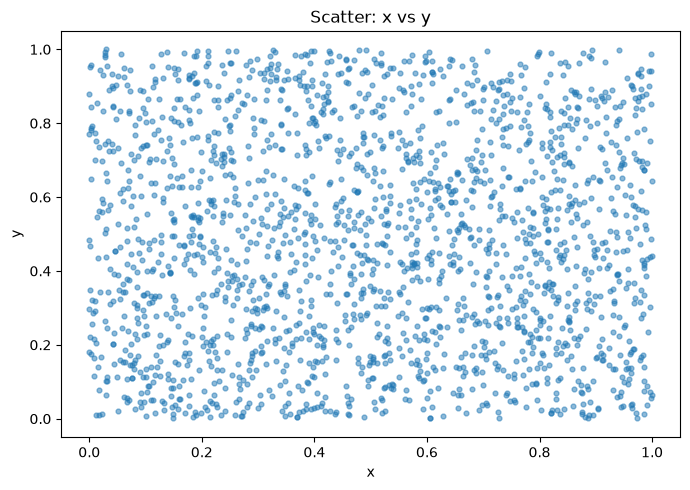

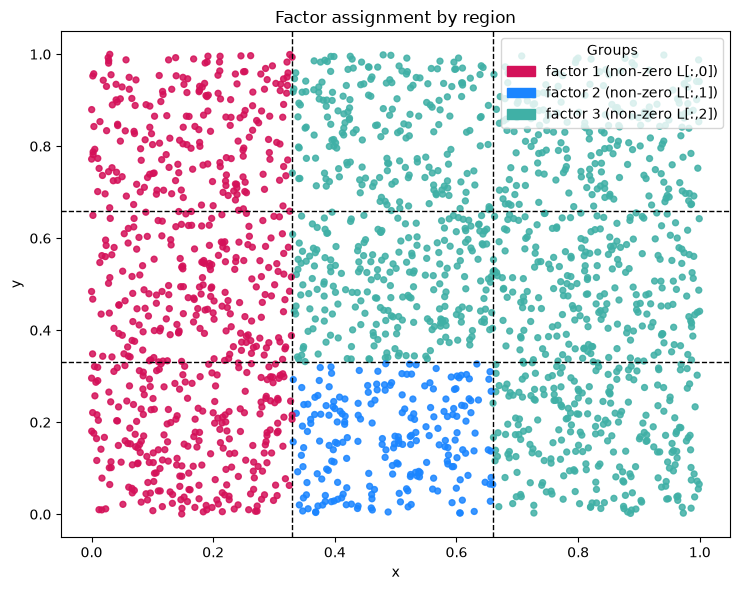

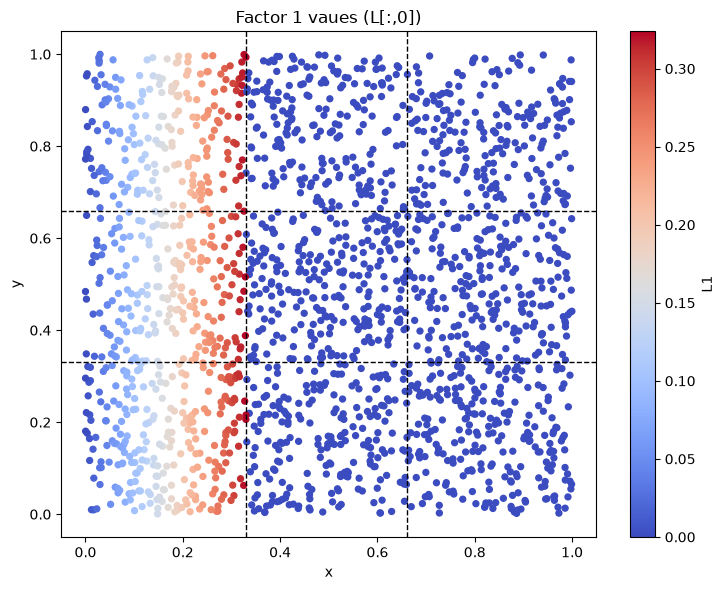

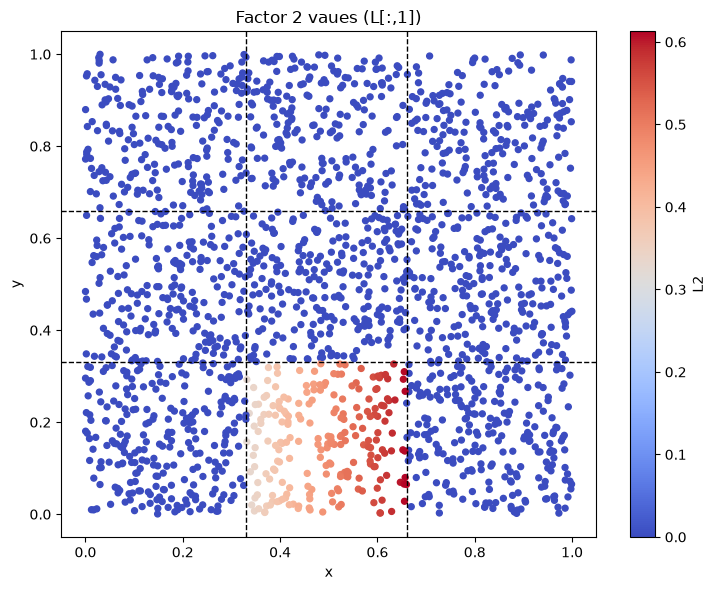

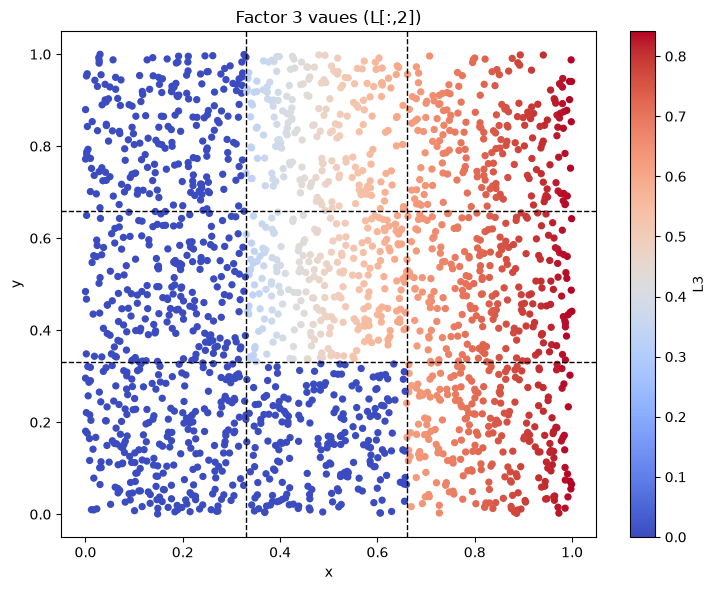

In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =========================
# Config & Reproducibility
# =========================
SEED = 1
N = 2000          # number of (x,y) points
M = 200           # number of features (columns) in f
BOUNDARIES = (0.33, 0.66)  # vertical/horizontal guide lines
NOISE_STD = 1.0   # std-dev for observation noise in Z

torch.manual_seed(SEED)

# =========================
# 1) Random uniform data
# =========================
x = torch.rand(N)
y = torch.rand(N)
X = torch.stack([x, y], dim=1)  # (N, 2) -- kept for clarity/optionally used later

# Quick scatter of x vs y
plt.figure(figsize=(7, 5))
plt.scatter(x.numpy(), y.numpy(), alpha=0.5, s=12)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter: x vs y")
plt.tight_layout()
plt.show()

# =========================
# 2) Generate f (3 x M)
#    f[0,i] ~ t1_i * N(0,1), f[1,i], f[2,i] ~ t2_i * N(0,1)
# =========================
t1 = torch.randint(0, 2, (M,), dtype=torch.float32)  # {0,1}
t2 = torch.randint(0, 2, (M,), dtype=torch.float32)  # {0,1}

f0 = t1 * torch.randn(M)
f1 = t2 * torch.randn(M)
f2 = t2 * torch.randn(M)
f  = torch.stack([f0, f1, f2], dim=0)  # (3, M)

# =========================
# 3) Build L (N x 3) + factor labels
# =========================
L = torch.zeros(N, 3, dtype=torch.float32)

b1, b2 = BOUNDARIES
mask1 = x < b1
mask2 = (~mask1) & (x < b2) & (y < b1)  # second region
mask3 = ~(mask1 | mask2)                # everything else

# Nonzero loadings by region (note: original logic used sin(x) for all three)
L[mask1, 0] = torch.sin(x[mask1])
L[mask2, 1] = torch.sin(x[mask2])
L[mask3, 2] = torch.sin(x[mask3])

# Integer factor labels in {1,2,3}
factor = torch.zeros(N, dtype=torch.long)
factor[mask1] = 1
factor[mask2] = 2
factor[mask3] = 3

# =========================
# 4) Factor visualization
# =========================
colors = ["#D41159", "#1A85FF", "#40B0A6"]  # red, blue, teal
color_map = {1: colors[0], 2: colors[1], 3: colors[2]}
point_colors = [color_map[int(k)] for k in factor.tolist()]

plt.figure(figsize=(7.5, 6))
plt.scatter(x.numpy(), y.numpy(), c=point_colors, s=18, alpha=0.85)
for v in (b1, b2):
    plt.axhline(v, color="black", linestyle="--", linewidth=1)
    plt.axvline(v, color="black", linestyle="--", linewidth=1)
plt.title("Factor assignment by region")
plt.xlabel("x")
plt.ylabel("y")

# Legend (explicit: red = non-zero L[:,0], etc.)
handles = [
    mpatches.Patch(color=colors[0], label="factor 1 (non-zero L[:,0])"),
    mpatches.Patch(color=colors[1], label="factor 2 (non-zero L[:,1])"),
    mpatches.Patch(color=colors[2], label="factor 3 (non-zero L[:,2])"),
]
plt.legend(handles=handles, title="Groups", loc="best", frameon=True)
plt.tight_layout()
plt.show()

# =========================
# 5) Individual factor heatmaps (L1, L2, L3 as color)
# =========================
for i in range(3):
    plt.figure(figsize=(7.5, 6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=L[:, i].numpy(),
        cmap="coolwarm",  # shows magnitude of L[:,i]
        s=18
    )
    for v in (b1, b2):
        plt.axhline(v, color="black", linestyle="--", linewidth=1)
        plt.axvline(v, color="black", linestyle="--", linewidth=1)
    plt.title(f"Factor {i+1} vaues (L[:,{i}])")
    plt.xlabel("x")
    plt.ylabel("y")
    cbar = plt.colorbar()
    cbar.set_label(f"L{i+1}")
    plt.tight_layout()
    plt.show()

# =========================
# 6) Generate observations Z = L @ f + noise
# =========================
noise = NOISE_STD * torch.randn(N, M)
Z = L @ f + noise  # (N, M)

# Optional sanity checks
assert L.shape == (N, 3)
assert f.shape == (3, M)
assert Z.shape == (N, M)


We will factorize the matrix Z using 4 different models.


* EBMF using point mass Laplace without using side information
* cEBMF using a "covariate moderated adaptive shrinkage prior " (cash) $ g(x,y) = \pi_0(x,y) \delta_0 + \sum_{m=1}^M \pi_m (x,y) N(0, \sigma_m^2)  $
* cEBMF using a "covariate moderated generalized binary prior" (cbg) $ g(x,y) = \pi_0(x,y) \delta_0 + (1-\pi_0(x,y))  N(\mu, \sigma_m^2)  $
* cEBMF using a "emprirical mixture of density networks" (emdn) $ g(x,y) = \  \sum_{m=1}^M \pi_m (x,y) N(\mu(x,y), \sigma_m(x,y)^2)  $

Fitting the model without account for the 2d side information

In [2]:
from cebmf_torch import cEBMF
mycebmf=  cEBMF(data=Z ) 
mycebmf.initialise_factors()
mycebmf.fit(10)

CEBMFResult(L=tensor([[-6.7597e+00, -1.4332e-02,  1.8322e+00,  7.4405e-09, -1.7140e-07],
        [-1.2728e-01, -8.6279e-02,  2.0286e+00,  5.9873e-08, -7.0834e-08],
        [-1.6565e+00, -1.5823e-02, -1.1584e-02, -3.5372e-08, -4.6365e-07],
        ...,
        [-6.3494e+00, -9.7500e-01,  1.8474e-02, -1.5801e-08,  5.3093e-07],
        [-1.1016e-01,  6.2749e-02,  2.8442e+00,  6.9965e-08, -1.3878e-08],
        [-9.9254e-02,  1.2566e-01,  1.3082e+00, -2.2994e-08,  6.5559e-08]],
       device='cuda:0'), F=tensor([[-1.3574e-01,  1.4970e-01, -8.4927e-02,  1.7704e-20, -9.3584e-20],
        [ 1.6497e-01,  1.4325e-01,  3.9474e-04,  6.8254e-22, -4.8811e-20],
        [-5.1116e-04, -6.7893e-04,  5.7606e-02,  1.2307e-20, -2.6547e-19],
        [-5.5548e-02,  1.2525e-01,  6.6624e-02, -6.7906e-20,  2.1912e-20],
        [ 1.5923e-05, -2.8374e-02,  6.6554e-02, -1.0835e-19, -7.5139e-20],
        [ 1.1018e-03,  1.7564e-03, -4.5967e-04,  6.2161e-21,  1.4430e-20],
        [-1.2126e-05, -9.3931e-03, -5.1897e-0

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

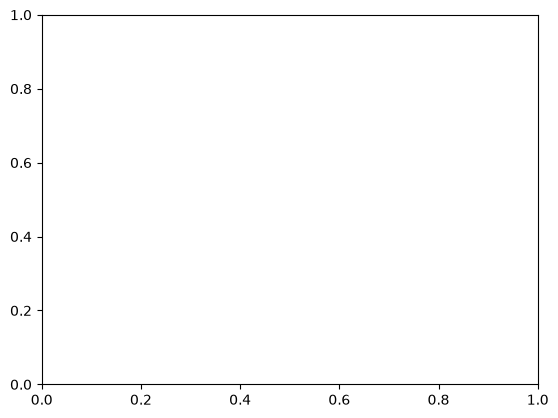

In [ ]:
mycebmf31=  cEBMF(data=Z, X_l=X,
                 prior_L="cgb_sharp" , allow_backfitting=False) 
mycebmf31.initialise_factors()
mycebmf31.fit(10)

 

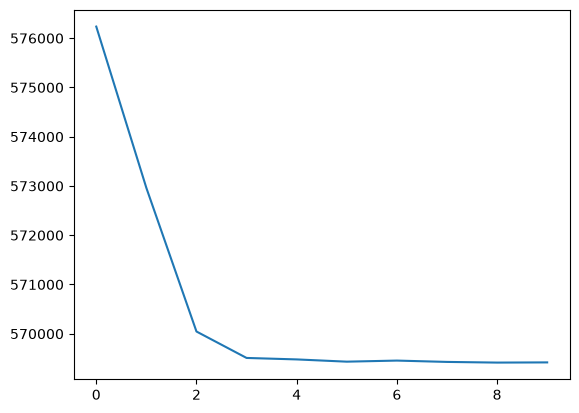

In [18]:
plt.plot( torch.stack(mycebmf31.obj).detach().cpu().numpy())

Fitting the cEBMF model


Here we store the side information for the rows $L$ in the matrix $X$ that we pass in argument X_l (covariate for L)
Using prior   a "covariate moderated adaptive shrinkage prior " (cash) $ g(x,y) = \pi_0(x,y) \delta_0 + \sum_{m=1}^M \pi_m (x,y) N(0, \sigma_m^2)  $


In [20]:
mycebmf11=  cEBMF(data=Z, X_l=X,
                 prior_L="cash" , allow_backfitting=False) 
mycebmf11.initialise_factors()
mycebmf11.fit(10)


CEBMFResult(L=tensor([[-6.9293e+00, -5.3066e-40,  3.7035e-21,  0.0000e+00,  0.0000e+00],
        [-1.9848e-12,  0.0000e+00,  2.2686e+00,  0.0000e+00,  0.0000e+00],
        [-1.9518e+00,  0.0000e+00, -1.3472e-05,  0.0000e+00,  0.0000e+00],
        ...,
        [-6.5172e+00,  0.0000e+00,  3.2324e-19,  0.0000e+00,  0.0000e+00],
        [-5.1648e-16,  2.9459e-25,  2.8320e+00,  0.0000e+00,  0.0000e+00],
        [-2.0326e-21,  1.0957e-20,  1.6830e+00,  0.0000e+00,  0.0000e+00]],
       device='cuda:0'), F=tensor([[-1.3403e-01,  1.5585e-01, -1.0117e-01,  0.0000e+00,  0.0000e+00],
        [ 1.6416e-01,  1.5416e-01,  9.7166e-04,  0.0000e+00,  0.0000e+00],
        [-4.8928e-04, -9.9735e-04,  4.7125e-02,  0.0000e+00,  0.0000e+00],
        [-5.5091e-02,  1.2788e-01,  9.0394e-02,  0.0000e+00,  0.0000e+00],
        [ 1.7126e-05, -3.9136e-02,  8.0440e-02,  0.0000e+00,  0.0000e+00],
        [ 9.4838e-04,  2.7638e-03,  5.4309e-04,  0.0000e+00,  0.0000e+00],
        [-2.5155e-05, -1.2159e-02, -1.2403e-0

The ELBO is not purely monotonic for cEBMF using because the prior learning uses SGD

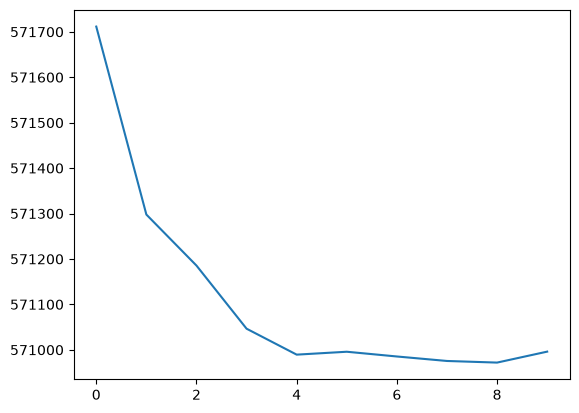

In [21]:

plt.plot(torch.stack(mycebmf11.obj).detach().cpu().numpy())

Fitting the cEBMF model using a "covariate moderated generalized binary prior" (cbg) $ g(x,y) = \pi_0(x,y) \delta_0 + (1-\pi_0) (x,y) N(\mu, \sigma_m^2)  $
 

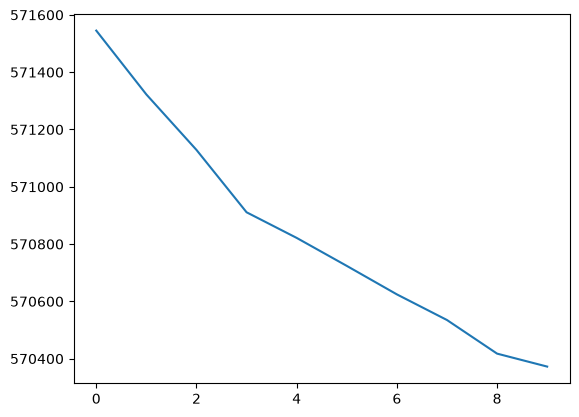

In [22]:
mycebmf12=  cEBMF(data=Z, X_l=X,
                 prior_L="cgb" , allow_backfitting=False) 
mycebmf12.initialise_factors()
mycebmf12.fit(10)

plt.plot(torch.stack(mycebmf12.obj).detach().cpu().numpy())

Fitting the cEBMF model using a "emprirical mixture of density networks" (emdn) $ g(x,y) = \  \sum_{m=1}^M \pi_m (x,y) N(\mu(x,y), \sigma_m(x,y)^2)  $

In [23]:
mycebmf13=  cEBMF(data=Z, X_l=X,
                 prior_L="emdn", allow_backfitting=False) 
mycebmf13.initialise_factors()
mycebmf13.fit(10)



CEBMFResult(L=tensor([[-6.8168, -0.1515,  0.0245, -0.1378, -0.1401],
        [-0.1986, -0.0960,  3.2339,  0.4169, -0.5029],
        [-3.6938, -0.0748,  0.0098, -0.2344, -0.2132],
        ...,
        [-6.2153, -0.1019,  0.0321, -0.2642,  0.5818],
        [-0.2008, -0.0591,  3.0851,  0.2232,  0.9384],
        [-0.2034, -0.0360,  2.7724, -0.1257,  0.3136]], device='cuda:0'), F=tensor([[-1.4155e-01,  1.6773e-01, -1.0705e-01,  7.1925e-04, -1.8812e-03],
        [ 1.6646e-01,  1.1364e-01,  2.7170e-02, -4.4501e-04, -2.0627e-03],
        [-3.4248e-04, -7.2675e-04,  5.6035e-02,  2.8656e-04, -2.6484e-01],
        [-5.9320e-02,  1.3439e-01,  8.6783e-02, -1.0908e-03, -2.5654e-03],
        [ 7.4348e-05, -3.5253e-02,  7.8532e-02, -9.3753e-04, -8.0950e-04],
        [ 1.3690e-03,  3.3445e-03,  1.0036e-03,  1.2022e-03,  8.8766e-04],
        [ 5.6035e-05, -9.9562e-03, -3.0216e-03, -1.6765e-01,  2.8732e-03],
        [-1.9973e-01,  1.7864e-01,  2.6188e-02,  4.9142e-04, -6.9181e-05],
        [-1.3274e-04, 

we can visualized the corresponding values to the negative ELBO (lower the better)

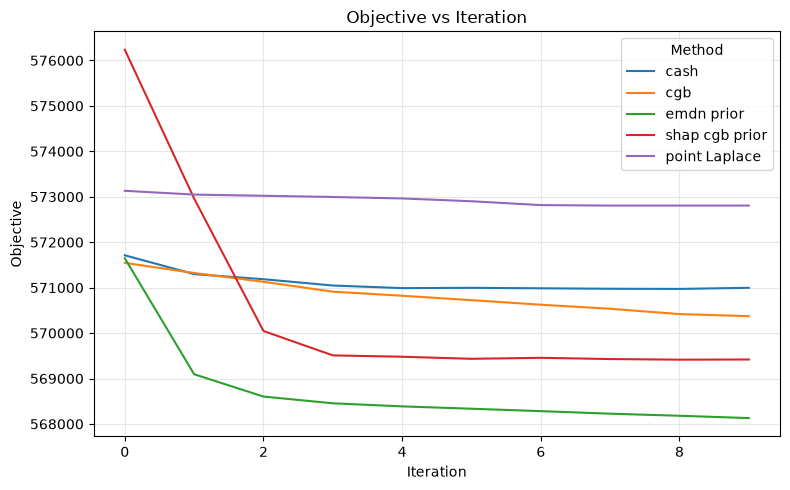

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def to1d(a):
    if isinstance(a, torch.Tensor):
        return a.detach().cpu().flatten().numpy()
    return np.asarray(a).ravel()

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(to1d(torch.stack(mycebmf11.obj).detach().cpu().numpy()), label="cash")
ax.plot(to1d(torch.stack(mycebmf12.obj).detach().cpu().numpy()),  label="cgb")
ax.plot(to1d(torch.stack(mycebmf13.obj).detach().cpu().numpy()),  label="emdn prior")
ax.plot(to1d(torch.stack(mycebmf31.obj).detach().cpu().numpy()),  label="shap cgb prior")
ax.plot(to1d(torch.stack(mycebmf.obj).detach().cpu().numpy()),   label="point Laplace")

ax.set_title("Objective vs Iteration")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective")
ax.legend(title="Method", loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


The results is not surprising as in this case only the emdn prior can recover the data generating process thus leading to a better fit.


The worst is acheived by the EBMF model with point Laplace which is the least flexible model


Noe 

TypeError: unsupported operand type(s) for -: 'numpy.ndarray' and 'Tensor'

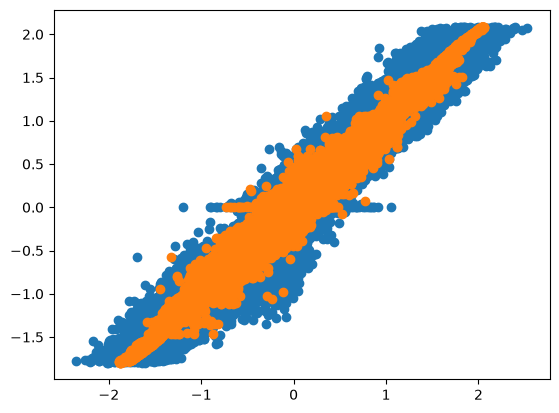

In [28]:
mycebmf._update_fitted_value()
mycebmf11._update_fitted_value()
mycebmf12._update_fitted_value()
mycebmf13._update_fitted_value()
mycebmf31._update_fitted_value()

plt.scatter(mycebmf.Y_fit.detach().cpu().numpy(),L@f)
plt.scatter(mycebmf13.Y_fit.detach().cpu().numpy(),L@f)
print("RMSE Point Laplace",torch.mean((mycebmf.Y_fit.detach().cpu().numpy()-L@f).pow(2)))

print("RMSE cash",torch.mean((mycebmf11.Y_fit.detach().cpu().numpy()-L@f).pow(2)))
print("RMSE cgb",torch.mean((mycebmf12.Y_fit.detach().cpu().numpy()-L@f).pow(2)))
print("RMSE emdn",torch.mean((mycebmf13.Y_fit.detach().cpu().numpy()-L@f).pow(2)))
print("RMSE emdn",torch.mean((mycebmf31.Y_fit.detach().cpu().numpy()-L@f).pow(2)))

Fitted factors (emdn prior)

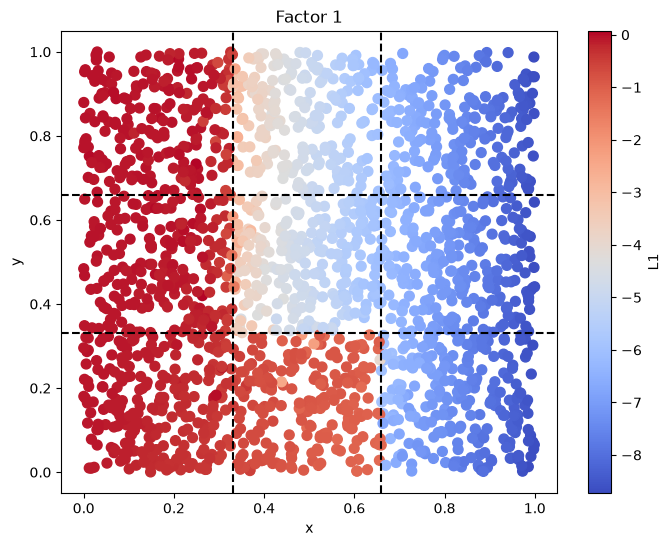

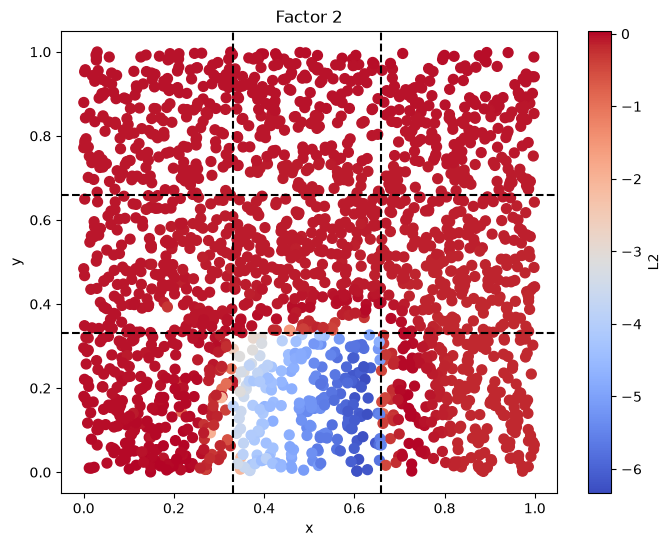

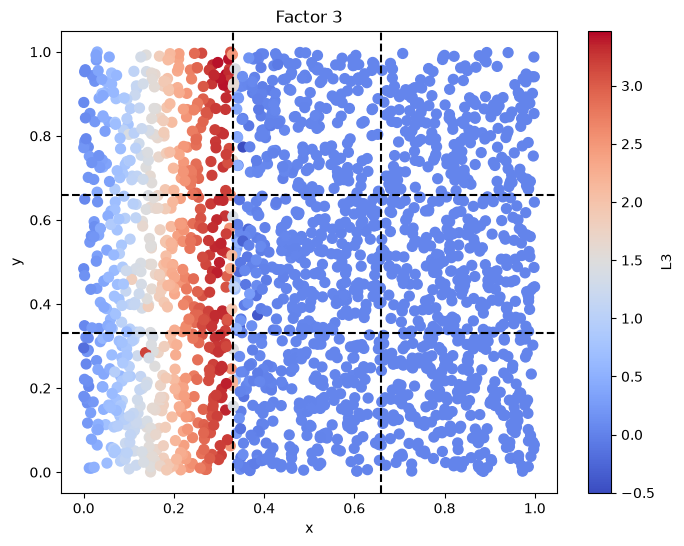

In [30]:
for i in range(3):
    plt.figure(figsize=(8,6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=mycebmf13.L[:, i].detach().cpu().numpy(),
        cmap="coolwarm",
        s=50
    )
    for v in [0.33, 0.66]:
        plt.axhline(v, color="black", linestyle="--")
        plt.axvline(v, color="black", linestyle="--")
    plt.title(f"Factor {i+1}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar(label=f"L{i+1}")
    plt.show()


Fitted factors (point Laplace)

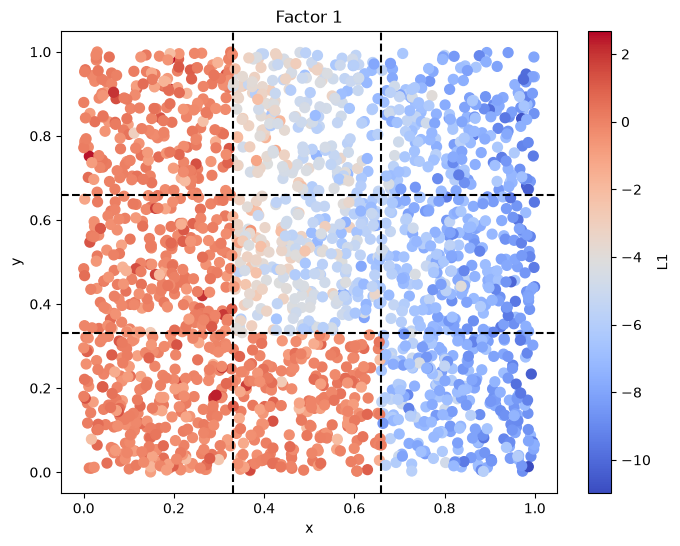

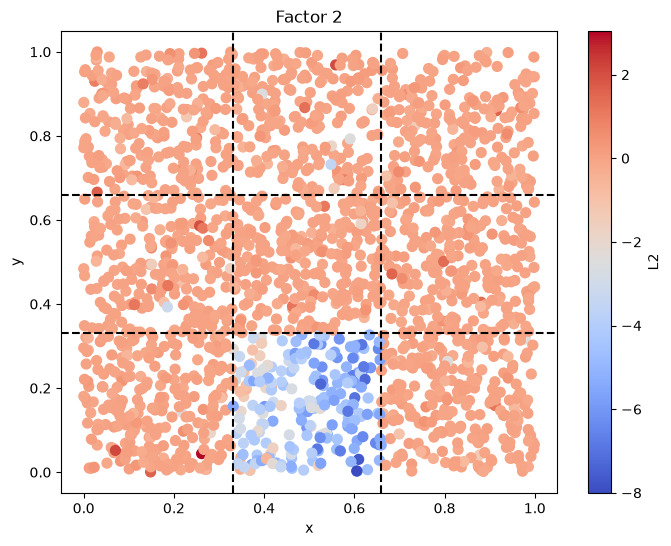

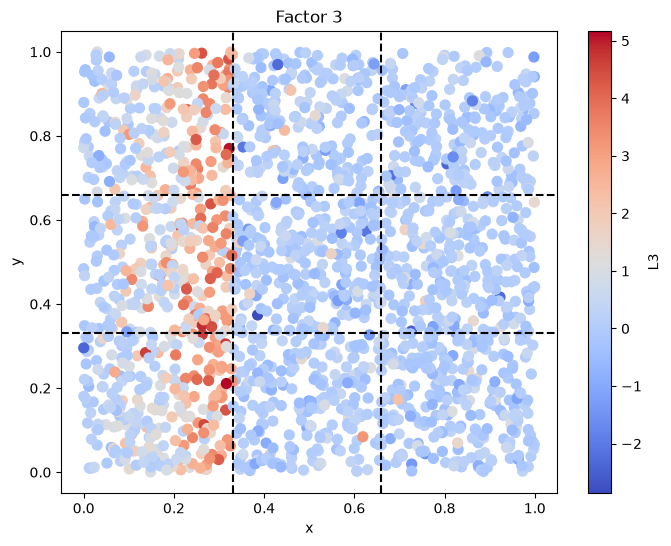

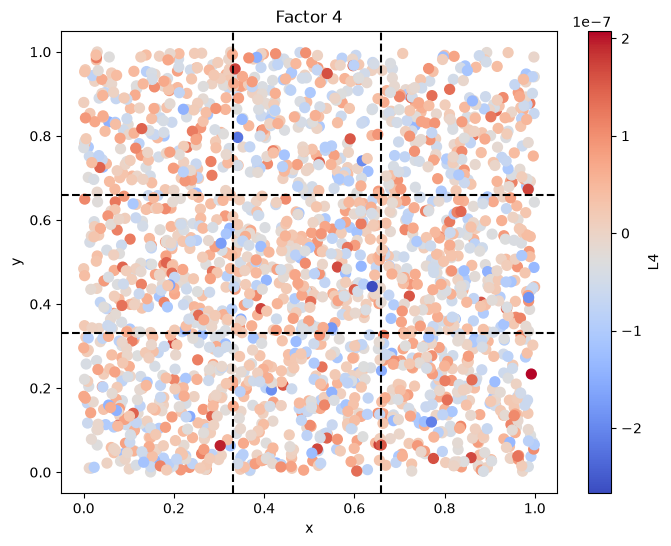

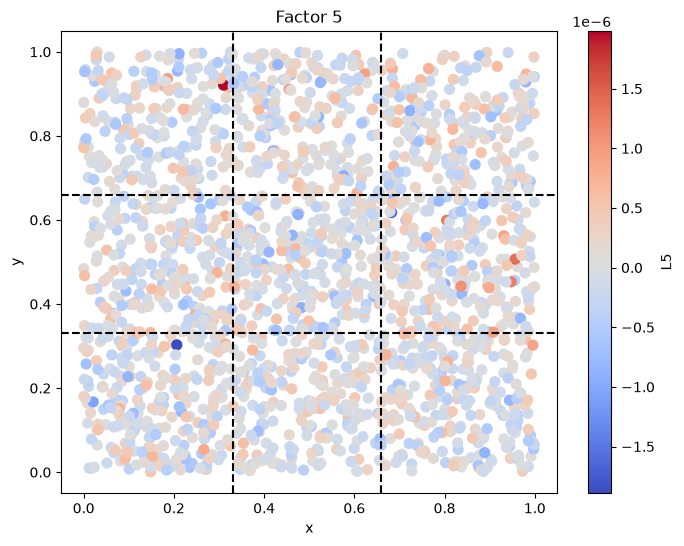

In [31]:
for i in range(5):
    plt.figure(figsize=(8,6))
    plt.scatter(
        x.numpy(),
        y.numpy(),
        c=mycebmf.L[:, i].detach().cpu().numpy(),
        cmap="coolwarm",
        s=50
    )
    for v in [0.33, 0.66]:
        plt.axhline(v, color="black", linestyle="--")
        plt.axvline(v, color="black", linestyle="--")
    plt.title(f"Factor {i+1}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.colorbar(label=f"L{i+1}")
    plt.show()


We can visulaized the fitted factor for the different prior 

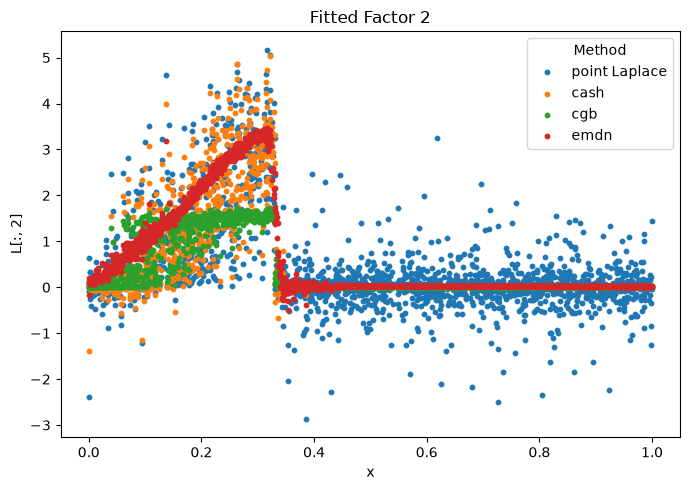

In [32]:
k = 2

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(x.detach().cpu().numpy(), mycebmf.L[:,k].detach().cpu().numpy(), s=10, label="point Laplace")
ax.scatter(x.detach().cpu().numpy(), mycebmf11.L[:,k].detach().cpu().numpy(), s=10, label="cash")
ax.scatter(x.detach().cpu().numpy(), mycebmf12.L[:,k].detach().cpu().numpy(), s=10, label="cgb")
ax.scatter(x.detach().cpu().numpy(), mycebmf13.L[:,k].detach().cpu().numpy(), s=10, label="emdn")

ax.set_title(f"Fitted Factor {k}")
ax.set_xlabel("x"); ax.set_ylabel(f"L[:, {k}]")
ax.legend(title="Method", loc="best")
plt.tight_layout()
plt.show()
